In [ ]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt


In [5]:
ruta01 = r'DatosFicticios/catalogo_productos.csv'
ruta02 = r'DatosFicticios/ventas_ficticias_santiago_202612.csv'
ruta03 = r'DatosFicticios/detalle_pedidos_santiago_202612.xlsx'

catalogo_productos = pd.read_csv(ruta01)
ventas_ficticias = pd.read_csv(ruta02)
detalle_pedidos = pd.read_excel(ruta03)

Primero analizamos completamente el Catálogo de los Productos

In [12]:
catalogo_productos.head()

,SKU,Descripción SKU,Largo_cm,Ancho_cm,Alto_cm,Volumen_unitario_m3,Peso_unitario_kg,Tipo_embalaje
0,SKU-00001,Martillo carpintero,33.4,11.5,4.1,0.001575,1.006,A granel
1,SKU-00002,Escalera aluminio 4 peldaños,118.8,44.3,14.5,0.076311,7.662,Embalaje personalizado
2,SKU-00003,Cinta aisladora,10.1,9.8,1.9,0.000188,0.131,A granel
3,SKU-00004,Silicona cartucho,22.8,4.9,5.1,0.000570,0.290,A granel
4,SKU-00005,Lámpara mesa,36.5,24.7,24.7,0.022268,2.362,Caja propia


In [13]:
print(catalogo_productos['SKU'].nunique())
print(catalogo_productos['Descripción SKU'].nunique())

900
36


Tenemos 900 SKU para 36 productos?

In [14]:
catalogo_productos.isnull().sum()

SKU                    0
Descripción SKU        0
Largo_cm               0
Ancho_cm               0
Alto_cm                0
Volumen_unitario_m3    0
Peso_unitario_kg       0
Tipo_embalaje          0
dtype: int64

No tenemos valores nulos

---
Continuamos entonces con el análisis de las ventas

In [15]:
ventas_ficticias.head()

,RUT,Nombre cliente,Dirección cliente,Fecha de Pedido,Número de Orden,Monto Pedido,Fecha de despacho Solicitada
0,14512240-4,Cliente Nuevo 14512240,AV. MATTA 5370 DEPTO 994 ESTACIÓN CENTRAL SANT...,2026-12-01,ORD-CL-202612-000001,123929,2026-12-02
1,17.313.403-1,Cliente 17313403,"Av. La Florida 7678, Macul, Santiago, Chile",2026-12-01,ORD-CL-202612-000002,118942,2026-12-03
2,7941056 - 6,Cliente Nuevo 7941056,"av. kennedy 5315, depto 694, independencia, sa...",2026-12-01,ORD-CL-202612-000003,115798,2026-12-04
3,18.305.966-9,Cliente 18305966,"Calle San Antonio 8832, Lo Prado, Santiago, Chile",2026-12-01,ORD-CL-202612-000004,240273,2026-12-03
4,20.329.309-9,Cliente Nuevo 20329309,Calle Catedral 6899 Depto 1132 Independencia S...,2026-12-01,ORD-CL-202612-000005,230875,2026-12-04


Tenemos Nombre Clientes, donde este se contruye con (Cliente|Cliente Nuevo + RUT sin DV) Dirección Cliente, separadas por comas, fechas de pedido y el despacho

In [16]:
ventas_ficticias.isnull().sum()

RUT                             0
Nombre cliente                  0
Dirección cliente               0
Fecha de Pedido                 0
Número de Orden                 0
Monto Pedido                    0
Fecha de despacho Solicitada    0
dtype: int64

In [17]:
print(
ventas_ficticias['RUT'].nunique()
)
print(
ventas_ficticias['Nombre cliente'].nunique()
)
print(
ventas_ficticias['Dirección cliente'].nunique()
)

3449
2081
3947


Tengo Clientes con más direcciones, Nombre Cliente al parecer es más inútil que otra cosa  
Evaluamos desglosar la dirección de los Clinetes

In [18]:
ventas_ficticias['Dirección cliente']

0       AV. MATTA 5370 DEPTO 994 ESTACIÓN CENTRAL SANT...
1             Av. La Florida 7678, Macul, Santiago, Chile
2       av. kennedy 5315, depto 694, independencia, sa...
3       Calle San Antonio 8832, Lo Prado, Santiago, Chile
4       Calle Catedral 6899 Depto 1132 Independencia S...
                              ...                        
4175    calle arturo prat 4349, depto 777, independenc...
4176    Calle San Antonio 8089 Depto 2002 La Reina San...
4177    Av. Macul 9885 Depto 2154 Quinta Normal Santia...
4178    Av.  Irarrázaval 7578 Providencia Santiago de ...
4179    Av. Matta 5370 Depto 994 Estación Central Sant...
Name: Dirección cliente, Length: 4180, dtype: str

In [19]:
detalle_pedidos.head()

# Aquí tenemos la forma de mergear los dataframes, pero no es necesario hacerlo ahora. De todas formas, lo dejo aquí para que lo veamos en el futuro.
# Todos los Números de Orden en función de los números de orden

,Número de Orden,SKU,Descripción SKU,Cantidad,Largo_cm,Ancho_cm,Alto_cm,Volumen_unitario_m3,Peso_unitario_kg,Volumen_total_m3,Peso_total_kg
0,ORD-CL-202612-000001,SKU-00535,Taladro eléctrico,10,37.8,29.0,9.6,0.010524,2.553,0.105240,25.530
1,ORD-CL-202612-000001,SKU-00664,Rodillo pintura,4,28.5,24.9,7.8,0.005535,0.398,0.022140,1.592
2,ORD-CL-202612-000001,SKU-00469,Monitor 24 pulgadas,1,59.1,46.8,15.4,0.042595,5.133,0.042595,5.133
3,ORD-CL-202612-000001,SKU-00583,Sierra circular,2,45.6,33.6,14.8,0.022676,5.863,0.045352,11.726
4,ORD-CL-202612-000001,SKU-00097,Cable eléctrico 10m,3,23.9,25.5,7.9,0.004815,1.208,0.014445,3.624


Continuamos entonces con las direcciones, es importante no perder información y poder ver cómo podemos tener un dato limpio para poder hacer análisis de geolocalización, por ejemplo. Para esto, vamos a revisar las direcciones y ver si es posible limpiarlas o estandarizarlas de alguna forma.

In [20]:
# A ver cuanto se luce el Gepeto con esto.


# -----------------------------
# 2) NORMALIZACIÓN DE TEXTO
# -----------------------------
def normalize_text(s: str) -> str:
    if pd.isna(s):
        return None
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = s.replace("stgo", "santiago")
    s = s.replace("santiago de chile", "santiago chile")
    s = re.sub(r"\bav[.]?\b", "avenida", s)
    s = re.sub(r"\bdepto\b|\bdpto\b|\bdep\b", "depto", s)
    s = re.sub(r"[,;:]+", ",", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip(" ,")

COMMUNES = [
    "Estación Central", "Independencia", "Lo Prado", "Puente Alto", "Recoleta",
    "Providencia", "Ñuñoa", "La Florida", "Macul", "Peñalolén", "La Reina",
    "Quinta Normal", "Vitacura", "Las Condes", "Maipú", "San Miguel", "Santiago",
    "Cerrillos", "Cerro Navia", "Conchalí", "El Bosque", "Huechuraba",
    "La Cisterna", "La Granja", "La Pintana", "Lo Barnechea", "Lo Espejo",
    "Pedro Aguirre Cerda", "Pudahuel", "Quilicura", "Renca", "San Joaquín", "San Ramón"
]

COMMUNES_NORM = sorted(
    [(normalize_text(c), c) for c in COMMUNES],
    key=lambda x: len(x[0]),
    reverse=True
)

def extract_commune(address: str) -> str:
    s = normalize_text(address)
    if s is None:
        return None

    # eliminamos país/ciudad al final
    s = re.sub(r"\bchile\b\s*$", "", s).strip(" ,")
    s = re.sub(r"\bsantiago\b\s*$", "", s).strip(" ,")

    # buscamos comuna solo al final
    for c_norm, c_orig in COMMUNES_NORM:
        if re.search(r"(?:^|[\s,])" + re.escape(c_norm) + r"\s*$", s):
            return c_orig

    # fallback: últimas 4 palabras
    tail = " ".join(s.split()[-4:])
    for c_norm, c_orig in COMMUNES_NORM:
        if re.search(r"(?<!\w)" + re.escape(c_norm) + r"(?!\w)", tail):
            return c_orig

    return None

def extract_depto(address: str) -> str:
    s = normalize_text(address)
    if s is None:
        return None
    m = re.search(r"\bdepto\s+([a-z0-9\-]+)\b", s)
    return m.group(1) if m else None

def build_routing_address(address: str) -> str:
    """
    Dirección pensada para geocodificar / rutear.
    Remueve depto y deja una versión canónica.
    """
    s = normalize_text(address)
    comuna = extract_commune(address)

    if s is None:
        return None

    # quitar depto
    s = re.sub(r",?\s*\bdepto\s+[a-z0-9\-]+\b", "", s)

    # quitar cola geográfica para reconstruirla de forma estándar
    s = re.sub(r",?\s*\bchile\b\s*$", "", s).strip(" ,")
    s = re.sub(r",?\s*\bsantiago\b\s*$", "", s).strip(" ,")
    if comuna:
        s = re.sub(r",?\s*" + re.escape(normalize_text(comuna)) + r"\s*$", "", s).strip(" ,")

    # reconstrucción canónica
    if comuna:
        return f"{s}, {comuna}, Santiago, Chile"
    return f"{s}, Santiago, Chile"

ventas_ficticias["comuna"] = ventas_ficticias["Dirección cliente"].apply(extract_commune)
ventas_ficticias["depto"] = ventas_ficticias["Dirección cliente"].apply(extract_depto)
ventas_ficticias["direccion_ruteo"] = ventas_ficticias["Dirección cliente"].apply(build_routing_address)
ventas_ficticias["direccion_norm"] = ventas_ficticias["Dirección cliente"].apply(normalize_text)


In [21]:
detalle_pedidos.head()

,Número de Orden,SKU,Descripción SKU,Cantidad,Largo_cm,Ancho_cm,Alto_cm,Volumen_unitario_m3,Peso_unitario_kg,Volumen_total_m3,Peso_total_kg
0,ORD-CL-202612-000001,SKU-00535,Taladro eléctrico,10,37.8,29.0,9.6,0.010524,2.553,0.105240,25.530
1,ORD-CL-202612-000001,SKU-00664,Rodillo pintura,4,28.5,24.9,7.8,0.005535,0.398,0.022140,1.592
2,ORD-CL-202612-000001,SKU-00469,Monitor 24 pulgadas,1,59.1,46.8,15.4,0.042595,5.133,0.042595,5.133
3,ORD-CL-202612-000001,SKU-00583,Sierra circular,2,45.6,33.6,14.8,0.022676,5.863,0.045352,11.726
4,ORD-CL-202612-000001,SKU-00097,Cable eléctrico 10m,3,23.9,25.5,7.9,0.004815,1.208,0.014445,3.624


In [22]:
# -----------------------------
# 3) ENRIQUECER DETALLE CON CATALOGO
# -----------------------------
# Solo agrega atributos que no estén ya en detalle
detalle_ext = detalle_pedidos.merge(
    catalogo_productos[["SKU", "Tipo_embalaje"]],
    on="SKU",
    how="left",
    validate="many_to_one"
)

# -----------------------------
# 4) AGREGAR DETALLE A NIVEL ORDEN
# -----------------------------
demanda_orden = (
    detalle_ext
    .groupby("Número de Orden", as_index=False)
    .agg(
        n_lineas=("SKU", "size"),
        n_skus=("SKU", "nunique"),
        unidades_totales=("Cantidad", "sum"),
        volumen_total_m3=("Volumen_total_m3", "sum"),
        peso_total_kg=("Peso_total_kg", "sum"),
        pieza_mas_larga_cm=("Largo_cm", "max"),
        pieza_mas_ancha_cm=("Ancho_cm", "max"),
        pieza_mas_alta_cm=("Alto_cm", "max"),
        tipos_embalaje=("Tipo_embalaje", lambda s: " | ".join(sorted(set(s.dropna()))))
    )
)

# -----------------------------
# 5) MERGE FINAL PARA VRP
# -----------------------------
vrp_orders = ventas_ficticias.merge(
    demanda_orden,
    on="Número de Orden",
    how="left",
    validate="one_to_one"
)

In [23]:
# Cobertura del merge
assert ventas_ficticias["Número de Orden"].nunique() == detalle_pedidos["Número de Orden"].nunique()

# Comuna extraída
print(vrp_orders["comuna"].isna().mean())

# Demanda faltante
print(vrp_orders[["peso_total_kg", "volumen_total_m3"]].isna().mean())

# Outliers logísticos
print(vrp_orders[["peso_total_kg", "volumen_total_m3"]].describe())

# Órdenes más pesadas / voluminosas
print(vrp_orders.nlargest(10, "peso_total_kg")[["Número de Orden", "peso_total_kg", "volumen_total_m3"]])
print(vrp_orders.nlargest(10, "volumen_total_m3")[["Número de Orden", "peso_total_kg", "volumen_total_m3"]])

0.0
peso_total_kg       0.0
volumen_total_m3    0.0
dtype: float64
       peso_total_kg  volumen_total_m3
count    4180.000000       4180.000000
mean      157.979706          1.080551
std       119.672632          0.942133
min         0.752000          0.001404
25%        69.774750          0.406296
50%       129.856000          0.830382
75%       215.942000          1.456508
max       984.130000          8.443656
           Número de Orden  peso_total_kg  volumen_total_m3
2855  ORD-CL-202612-002856        984.130          8.443656
3404  ORD-CL-202612-003405        809.761          6.569671
1952  ORD-CL-202612-001953        769.191          6.657617
545   ORD-CL-202612-000546        766.886          5.400970
913   ORD-CL-202612-000914        754.082          6.325490
1790  ORD-CL-202612-001791        753.308          6.331354
2878  ORD-CL-202612-002879        753.238          5.809709
1470  ORD-CL-202612-001471        743.451          5.347066
2917  ORD-CL-202612-002918        730.894 

In [24]:
vrp_orders.head()

,RUT,Nombre cliente,Dirección cliente,Fecha de Pedido,Número de Orden,Monto Pedido,Fecha de despacho Solicitada,comuna,depto,direccion_ruteo,direccion_norm,n_lineas,n_skus,unidades_totales,volumen_total_m3,peso_total_kg,pieza_mas_larga_cm,pieza_mas_ancha_cm,pieza_mas_alta_cm,tipos_embalaje
0,14512240-4,Cliente Nuevo 14512240,AV. MATTA 5370 DEPTO 994 ESTACIÓN CENTRAL SANT...,2026-12-01,ORD-CL-202612-000001,123929,2026-12-02,Estación Central,994,"avenida. matta 5370, Estación Central, Santiag...",avenida. matta 5370 depto 994 estacion central...,25,25,115,1.260186,188.366,124.4,46.8,25.1,A granel | Caja propia | Embalaje personalizado
1,17.313.403-1,Cliente 17313403,"Av. La Florida 7678, Macul, Santiago, Chile",2026-12-01,ORD-CL-202612-000002,118942,2026-12-03,Macul,NaN,"avenida. la florida 7678, Macul, Santiago, Chile","avenida. la florida 7678, macul, santiago, chile",20,19,106,4.239399,505.552,118.1,71.9,41.6,A granel | Caja propia | Embalaje personalizado
2,7941056 - 6,Cliente Nuevo 7941056,"av. kennedy 5315, depto 694, independencia, sa...",2026-12-01,ORD-CL-202612-000003,115798,2026-12-04,Independencia,694,"avenida. kennedy 5315, Independencia, Santiago...","avenida. kennedy 5315, depto 694, independenci...",14,14,48,1.898356,236.554,125.9,70.3,41.5,A granel | Caja propia | Embalaje personalizado
3,18.305.966-9,Cliente 18305966,"Calle San Antonio 8832, Lo Prado, Santiago, Chile",2026-12-01,ORD-CL-202612-000004,240273,2026-12-03,Lo Prado,NaN,"calle san antonio 8832, Lo Prado, Santiago, Chile","calle san antonio 8832, lo prado, santiago, chile",21,21,84,2.514063,317.365,125.1,66.8,26.2,A granel | Caja propia | Embalaje personalizado
4,20.329.309-9,Cliente Nuevo 20329309,Calle Catedral 6899 Depto 1132 Independencia S...,2026-12-01,ORD-CL-202612-000005,230875,2026-12-04,Independencia,1132,"calle catedral 6899, Independencia, Santiago, ...",calle catedral 6899 depto 1132 independencia s...,21,21,113,1.188721,245.264,122.1,70.1,24.6,A granel | Caja propia | Embalaje personalizado


In [33]:
print(vrp_orders['RUT'].nunique(), vrp_orders['Nombre cliente'].nunique(), vrp_orders['Dirección cliente'].nunique())

3449 2081 3947


In [34]:
# Vamos a verificar las direcciones
# Hacemos que ppodamos leer todas las fila

vrp_orders["direccion_ruteo"]

0       avenida. matta 5370, Estación Central, Santiag...
1        avenida. la florida 7678, Macul, Santiago, Chile
2       avenida. kennedy 5315, Independencia, Santiago...
3       calle san antonio 8832, Lo Prado, Santiago, Chile
4       calle catedral 6899, Independencia, Santiago, ...
                              ...                        
4175    calle arturo prat 4349, Independencia, Santiag...
4176    calle san antonio 8089, La Reina, Santiago, Chile
4177    avenida. macul 9885, Quinta Normal, Santiago, ...
4178    avenida. irarrazaval 7578, Providencia, Santia...
4179    avenida. matta 5370, Estación Central, Santiag...
Name: direccion_ruteo, Length: 4180, dtype: str

In [28]:
vrp_orders['peso_total_kg'].describe()

count    4180.000000
mean      157.979706
std       119.672632
min         0.752000
25%        69.774750
50%       129.856000
75%       215.942000
max       984.130000
Name: peso_total_kg, dtype: float64

In [29]:
vrp_orders['volumen_total_m3'].describe()

count    4180.000000
mean        1.080551
std         0.942133
min         0.001404
25%         0.406296
50%         0.830382
75%         1.456508
max         8.443656
Name: volumen_total_m3, dtype: float64

In [35]:
vrp_orders.to_excel("vrp_orders.xlsx", index=False, sheet_name="vrp_orders", engine='openpyxl')

In [38]:
vrp_orders.columns

Index(['RUT', 'Nombre cliente', 'Dirección cliente', 'Fecha de Pedido',
       'Número de Orden', 'Monto Pedido', 'Fecha de despacho Solicitada',
       'comuna', 'depto', 'direccion_ruteo', 'direccion_norm', 'n_lineas',
       'n_skus', 'unidades_totales', 'volumen_total_m3', 'peso_total_kg',
       'pieza_mas_larga_cm', 'pieza_mas_ancha_cm', 'pieza_mas_alta_cm',
       'tipos_embalaje'],
      dtype='str')

In [50]:
# Vemos cuantos pedidos por día tenemos en cada comuna
vrp_orders.groupby('comuna')['Fecha de Pedido'].count()
ord_per_day = vrp_orders.groupby(['Fecha de despacho Solicitada', 'comuna']).size()

In [51]:
ord_per_day=ord_per_day.to_frame(name='pedidos')
# Vemos el número de pedidos promedio por día en cada comuna


In [52]:
ord_per_day.groupby('comuna')['pedidos'].mean().sort_values(ascending=False)

comuna
La Florida          8.454545
Puente Alto         8.333333
Las Condes          7.794118
Estación Central    7.647059
Providencia         7.588235
Vitacura            7.424242
Santiago            7.393939
Peñalolén           7.393939
Maipú               7.294118
Independencia       7.257143
La Reina            7.228571
Lo Prado            7.029412
Recoleta            6.941176
Macul               6.852941
San Miguel          6.764706
Quinta Normal       6.470588
Ñuñoa               5.794118
Name: pedidos, dtype: float64

In [59]:
ord_per_day.head(20)

pedidos
Fecha de despacho Solicitada comuna                   
2026-12-02                   Estación Central        3
                             Independencia           1
                             La Reina                1
                             Lo Prado                1
                             Macul                   1
                             Maipú                   1
                             Providencia             1
                             Quinta Normal           1
                             Recoleta                3
                             Ñuñoa                   1
2026-12-03                   Estación Central        4
                             Independencia           8
                             La Florida              6
                             La Reina                4
                             Las Condes              3
                             Lo Prado                5
                             Macul                   9
                             Maipú                   4
                             Peñalolén               5
                             Providencia             7

In [61]:
orders_day = vrp_orders.groupby('Fecha de despacho Solicitada').size()

In [62]:
avg_orders_day = orders_day.mean()
avg_orders_day

np.float64(119.42857142857143)

In [63]:
orders_day.describe()

count     35.000000
mean     119.428571
std       39.610817
min        4.000000
25%      108.000000
50%      124.000000
75%      145.500000
max      181.000000
dtype: float64

In [68]:
orders_day_comuna = (
    vrp_orders
    .groupby(['Fecha de despacho Solicitada', 'comuna'])
    .size()
    .reset_index(name='ordenes')
)
avg_comuna = (
    orders_day_comuna
    .groupby('comuna')['ordenes']
    .mean()
    .sort_values(ascending=False)
)

print("Promedio pedidos/día por comuna:")
print(avg_comuna)

Promedio pedidos/día por comuna:
comuna
La Florida          8.454545
Puente Alto         8.333333
Las Condes          7.794118
Estación Central    7.647059
Providencia         7.588235
Vitacura            7.424242
Santiago            7.393939
Peñalolén           7.393939
Maipú               7.294118
Independencia       7.257143
La Reina            7.228571
Lo Prado            7.029412
Recoleta            6.941176
Macul               6.852941
San Miguel          6.764706
Quinta Normal       6.470588
Ñuñoa               5.794118
Name: ordenes, dtype: float64


<Axes: >

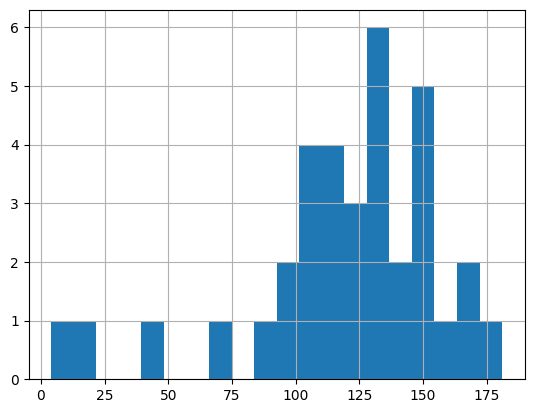

In [73]:
orders_day.hist(bins=20)